In [2]:
using CoolProp
using Statistics, DataFrames, GLM, StatsModels, Plots

In [3]:
# Pressure (Pa) and temperature (K) ranges
P_vals = collect(100e5:0.5e5:300e5)
T_vals = collect(273:1:300)

# 2D matrix: rows = P_vals, columns = T_vals
compressibility_vals = [PropsSI("ISOTHERMAL_COMPRESSIBILITY", "T", T, "P", P, "CO2") for P in P_vals, T in T_vals] # Compressibility in 1/Pa

# Example: compressibility_vals[i, j] corresponds to P_vals[i], T_vals[j]
# vec() flattens column-major, so P must vary fastest (outer) and T slowest (inner)
df = DataFrame(
    P = repeat(P_vals, outer=length(T_vals)),
    T = repeat(T_vals, inner=length(P_vals)),
    y = vec(compressibility_vals)
)

Row,P,T,y
,Float64,Int64,Float64
1,1.0e7,273,5.84428e-9
2,1.005e7,273,5.82729e-9
3,1.01e7,273,5.8104e-9
4,1.015e7,273,5.79363e-9
5,1.02e7,273,5.77697e-9
6,1.025e7,273,5.76042e-9
7,1.03e7,273,5.74397e-9
8,1.035e7,273,5.72763e-9
9,1.04e7,273,5.7114e-9


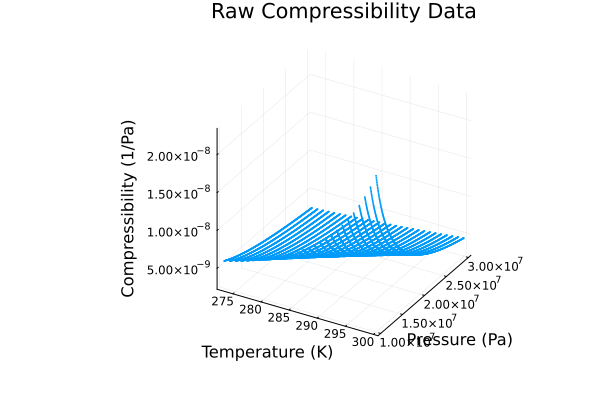

In [4]:
# Raw data plot as a 3D scatter: each point is one (T, P, compressibility) sample
T_grid = repeat(T_vals, inner=length(P_vals))
P_grid = repeat(P_vals, outer=length(T_vals))

scatter(
    T_grid,
    P_grid,
    vec(compressibility_vals),
    xlabel = "Temperature (K)",
    ylabel = "Pressure (Pa)",
    zlabel = "Compressibility (1/Pa)",
    title = "Raw Compressibility Data",
    markersize = 1,
    markerstrokewidth = 0,
    legend = false
 )

In [5]:
# Fit Model 

df.Ps = df.P/1e5
df.Ts = df.T

model = lm(@formula(log(y) ~ 1 + Ps + Ts + Ps^2 + Ts^2 + Ps&Ts + Ps^3 + Ts^3), df)


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

:(log(y)) ~ 1 + Ps + Ts + :(Ps ^ 2) + :(Ts ^ 2) + :(Ps ^ 3) + :(Ts ^ 3) + Ps & Ts

Coefficients:
─────────────────────────────────────────────────────────────────────────────────────────
                    Coef.     Std. Error        t  Pr(>|t|)      Lower 95%      Upper 95%
─────────────────────────────────────────────────────────────────────────────────────────
(Intercept)   0.0          NaN             NaN       NaN     NaN            NaN
Ps            0.00998551     0.000469086    21.29    <1e-97    0.00906602     0.010905
Ts            0.0          NaN             NaN       NaN     NaN            NaN
Ps ^ 2        7.64981e-5     1.92263e-6     39.79    <1e-99    7.27294e-5     8.02668e-5
Ts ^ 2       -0.000788697    1.10552e-6   -713.42    <1e-99   -0.000790864   -0.00078653
Ps ^ 3       -1

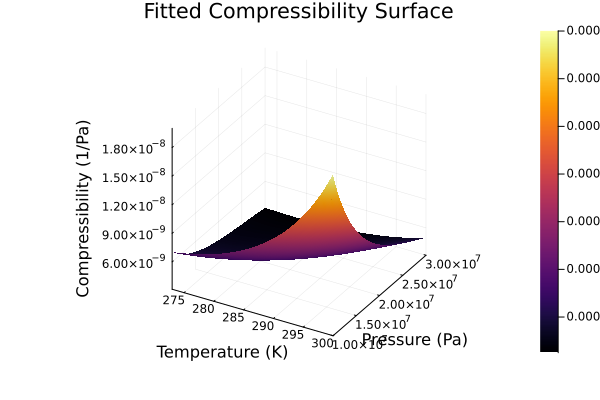

In [6]:

# Predict compressibility on the same P-T grid used for fitting
# Same column-major ordering as df: P varies fastest, T slowest
pred_df = DataFrame(
    P = repeat(P_vals, outer=length(T_vals)),
    T = repeat(T_vals, inner=length(P_vals))
)

pred_df.Ps = pred_df.P/1e5
pred_df.Ts = pred_df.T

pred_vals = predict(model, pred_df)
pred_vals = exp.(pred_vals)  # Since we fitted log(y), take exp to get y
pred_surface = reshape(pred_vals, length(P_vals), length(T_vals))

# Surface plot: x = T, y = P, z = predicted compressibility
surface(
    T_vals,
    P_vals,
    pred_surface,
    xlabel = "Temperature (K)",
    ylabel = "Pressure (Pa)",
    zlabel = "Compressibility (1/Pa)",
    title = "Fitted Compressibility Surface",
 )

In [ ]:
# Test Model Fit at a specific (T, P) point

coefficients = coef(model)
println("Coefficients: ", coefficients)
T = 300
P = 100e5

y = coefficients[1] + coefficients[2] * (P/1e5) + coefficients[3] * T + coefficients[4] * (P/1e5)^2 + coefficients[5] * T^2 + coefficients[6] * (P/1e5)^3 + coefficients[7] * T^3 + coefficients[8] * (P/1e5)*T 
y_compressibility = exp(y)  # Since we fitted log(y), take exp to get y

println("Predicted compressibility at T = ", T, " K and P = ", P, " Pa: ", y_compressibility, " 1/Pa")
println("Actual compressibility at T = ", T, " K and P = ", P, " Pa: ", PropsSI("ISOTHERMAL_COMPRESSIBILITY", "T", 300, "P", 100e5, "CO2"), " 1/Pa")

Coefficients: [0.0, 0.00998551244405563, 0.0, 7.64981296243389e-5, -0.0007886972357353244, -1.0044529893048498e-7, 2.0387386043642643e-6, -0.0001151110274036412]
Predicted compressibility at T = 300 K and P = 1.0e7 Pa: 2.000962400794754e-8 1/Pa
Actual compressibility at T = 300 K and P = 1.0e7 Pa: 2.2889994275309858e-8 1/Pa


In [8]:
# Model Fit Quality Metrics

println("\n===== FIT QUALITY (corrected data) =====")
r = residuals(model); yh = predict(model)
relerr = abs.(r) ./ df.y
println("R2                 = ", round(r2(model), digits=6))
println("adj R2             = ", round(adjr2(model), digits=6))
println("RMSE               = ", round(sqrt(mean(r.^2)), sigdigits=4))
println("y range            = ", round.(extrema(df.y), sigdigits=4))
println("y std              = ", round(std(df.y), sigdigits=4))
println("max |rel error|    = ", round(100*maximum(relerr), digits=3), " %")
println("mean |rel error|   = ", round(100*mean(relerr), digits=3), " %")



===== FIT QUALITY (corrected data) =====
R2                 = 0.981129
adj R2             = 0.981121
RMSE               = 0.05175
y range            = (2.83e-9, 2.289e-8)
y std              = 2.682e-9
max |rel error|    = 4.379961322743e9 %
mean |rel error|   = 8.51433180416e8 %
